# GLUE EDA (Hugging Face datasets for all tasks)

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import os
import numpy as np
from dataclasses import dataclass
from typing import Dict, List, Optional
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset

In [3]:
glue_tasks = [
    "cola",
    "sst2",
    "mrpc",
    "qqp",
    "stsb",
    "mnli",
    "qnli",
    "rte",
    "wnli",
    "ax"   # diagnostic; often only test
]

In [4]:
def get_text_fields(task_name):
    # Rough mapping of GLUE task -> text fields
    if task_name in ["sst2", "cola"]:
        return ["sentence"]
    if task_name in ["mrpc", "qqp"]:
        return ["sentence1", "sentence2"]
    if task_name in ["stsb"]:
        return ["sentence1", "sentence2"]
    if task_name in ["mnli", "qnli", "rte", "wnli", "ax"]:
        return ["premise", "hypothesis"] if task_name in ["mnli", "rte", "ax"] else ["question", "sentence"]
    return []

In [5]:
def eda_glue_task(task_name):
    print("=" * 80)
    print(f"GLUE task: {task_name}")
    ds = load_dataset("glue", task_name)

    for split in ds.keys():
        print(f"\nSplit: {split}")
        d = ds[split]
        print("Num examples:", len(d))
        print("Features:", d.features)

        # Label distribution (if classification)
        if "label" in d.features and str(d.features["label"].dtype) == "int64":
            labels = d["label"]
            counts = Counter(labels)
            print("Label distribution:", counts)

            # Plot label distribution
            plt.figure()
            plt.bar(counts.keys(), counts.values())
            plt.title(f"{task_name} - {split} label distribution")
            plt.xlabel("Label id")
            plt.ylabel("Count")
            plt.tight_layout()
            plt.show()

        # Text length distribution
        text_fields = get_text_fields(task_name)
        for field in text_fields:
            if field in d.column_names:
                lengths = [len(x.split()) for x in d[field]]
                print(f"{field} - mean length: {np.mean(lengths):.2f}, "
                      f"median: {np.median(lengths):.2f}, "
                      f"max: {np.max(lengths)}")

                plt.figure()
                plt.hist(lengths, bins=50)
                plt.title(f"{task_name} - {split} - {field} length distribution")
                plt.xlabel("Token count (whitespace)")
                plt.ylabel("Frequency")
                plt.tight_layout()
                plt.show()

        # Show a few examples
        print("\nSample examples:")
        for i in range(3):
            ex = d[i]
            print(f"Example {i}:")
            for k, v in ex.items():
                if isinstance(v, str):
                    print(f"  {k}: {v[:200]}{'...' if len(v) > 200 else ''}")
                else:
                    print(f"  {k}: {v}")
        print("-" * 80)

GLUE task: cola


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

cola/train-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

cola/validation-00000-of-00001.parquet:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

cola/test-00000-of-00001.parquet:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]


Split: train
Num examples: 8551
Features: {'sentence': Value('string'), 'label': ClassLabel(names=['unacceptable', 'acceptable']), 'idx': Value('int32')}
Label distribution: Counter({1: 6023, 0: 2528})


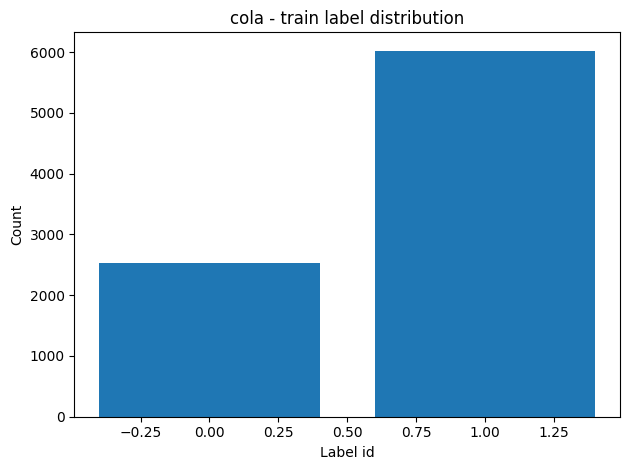

sentence - mean length: 7.70, median: 7.00, max: 42


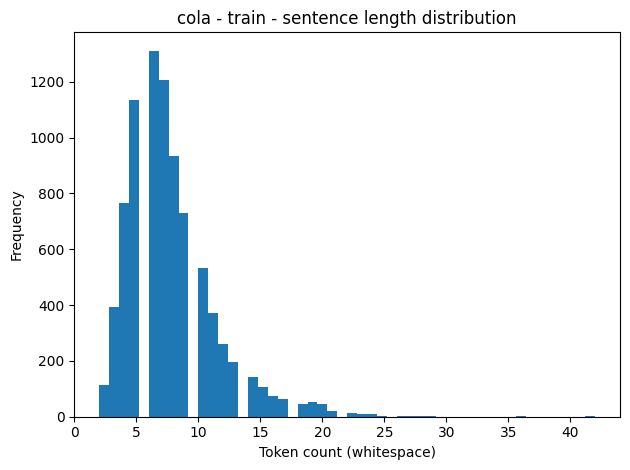


Sample examples:
Example 0:
  sentence: Our friends won't buy this analysis, let alone the next one we propose.
  label: 1
  idx: 0
Example 1:
  sentence: One more pseudo generalization and I'm giving up.
  label: 1
  idx: 1
Example 2:
  sentence: One more pseudo generalization or I'm giving up.
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: validation
Num examples: 1043
Features: {'sentence': Value('string'), 'label': ClassLabel(names=['unacceptable', 'acceptable']), 'idx': Value('int32')}
Label distribution: Counter({1: 721, 0: 322})


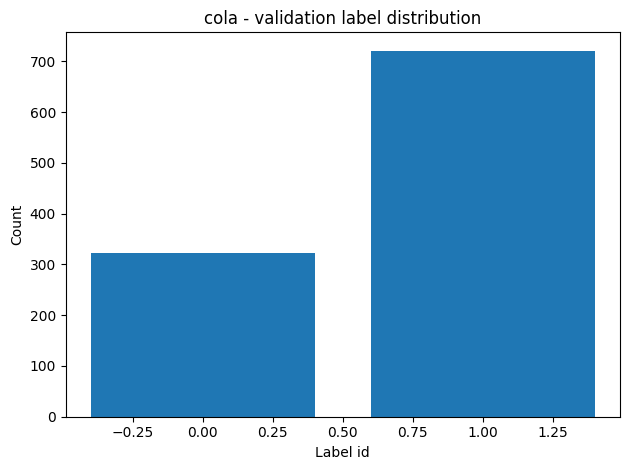

sentence - mean length: 7.92, median: 7.00, max: 29


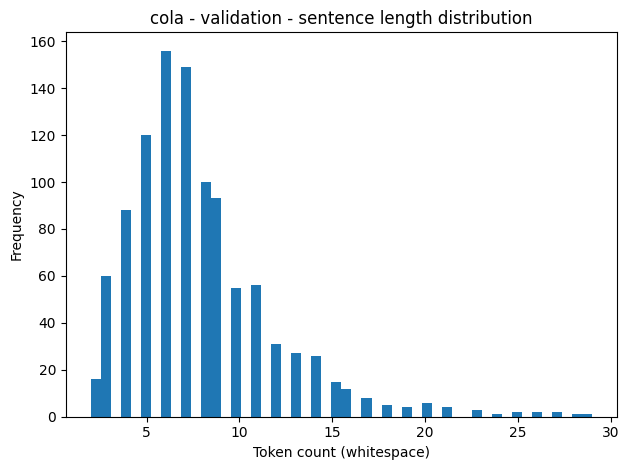


Sample examples:
Example 0:
  sentence: The sailors rode the breeze clear of the rocks.
  label: 1
  idx: 0
Example 1:
  sentence: The weights made the rope stretch over the pulley.
  label: 1
  idx: 1
Example 2:
  sentence: The mechanical doll wriggled itself loose.
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: test
Num examples: 1063
Features: {'sentence': Value('string'), 'label': ClassLabel(names=['unacceptable', 'acceptable']), 'idx': Value('int32')}
Label distribution: Counter({-1: 1063})


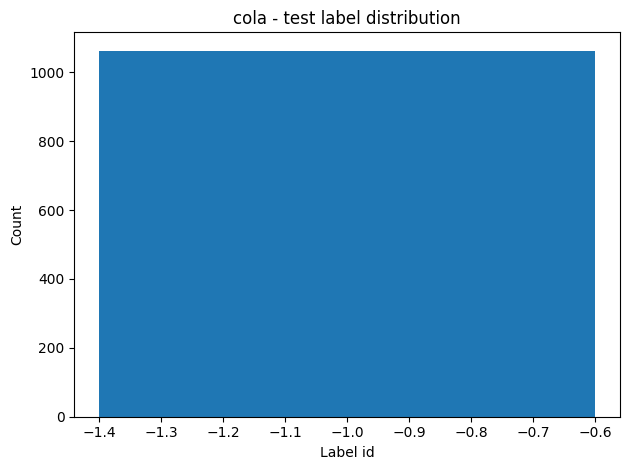

sentence - mean length: 7.80, median: 7.00, max: 26


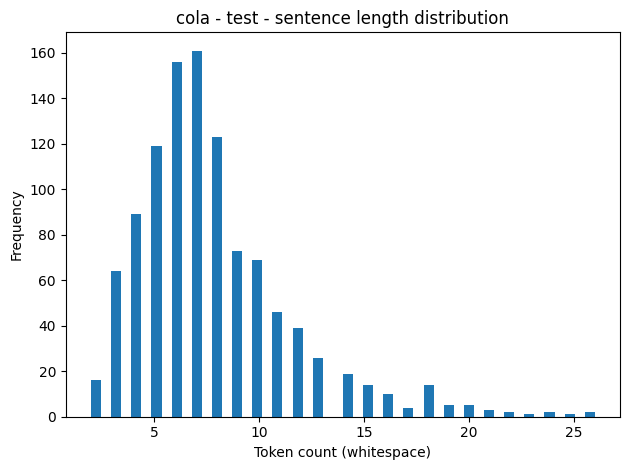


Sample examples:
Example 0:
  sentence: Bill whistled past the house.
  label: -1
  idx: 0
Example 1:
  sentence: The car honked its way down the road.
  label: -1
  idx: 1
Example 2:
  sentence: Bill pushed Harry off the sofa.
  label: -1
  idx: 2
--------------------------------------------------------------------------------
GLUE task: sst2


sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


Split: train
Num examples: 67349
Features: {'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive']), 'idx': Value('int32')}
Label distribution: Counter({1: 37569, 0: 29780})


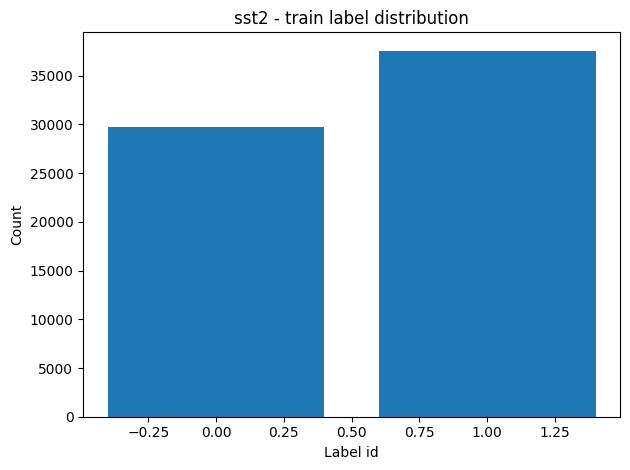

sentence - mean length: 9.41, median: 7.00, max: 52


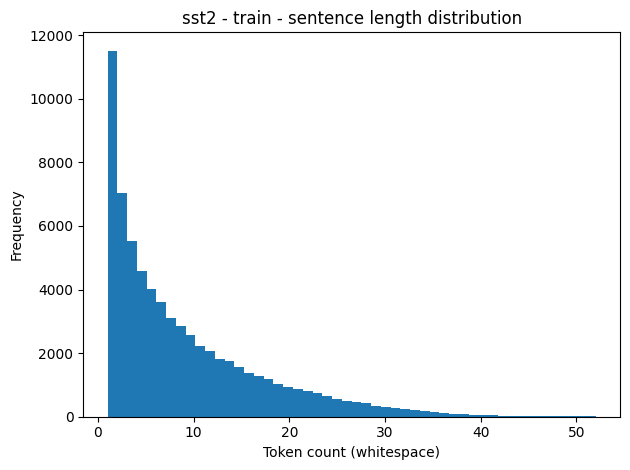


Sample examples:
Example 0:
  sentence: hide new secretions from the parental units 
  label: 0
  idx: 0
Example 1:
  sentence: contains no wit , only labored gags 
  label: 0
  idx: 1
Example 2:
  sentence: that loves its characters and communicates something rather beautiful about human nature 
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: validation
Num examples: 872
Features: {'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive']), 'idx': Value('int32')}
Label distribution: Counter({1: 444, 0: 428})


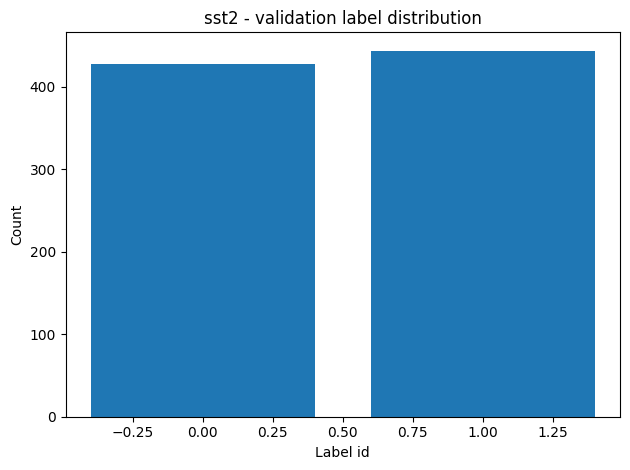

sentence - mean length: 19.55, median: 19.00, max: 47


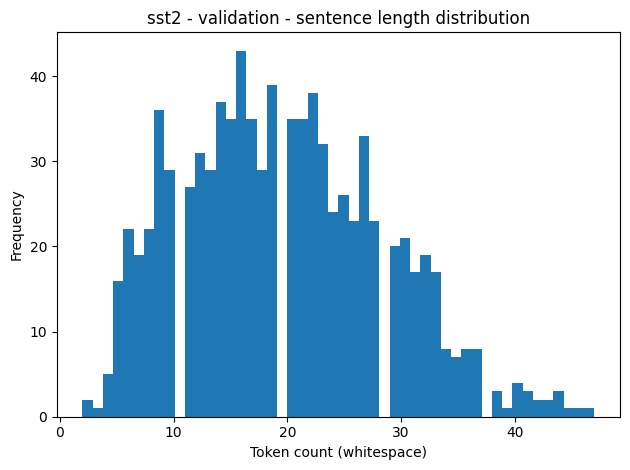


Sample examples:
Example 0:
  sentence: it 's a charming and often affecting journey . 
  label: 1
  idx: 0
Example 1:
  sentence: unflinchingly bleak and desperate 
  label: 0
  idx: 1
Example 2:
  sentence: allows us to hope that nolan is poised to embark a major career as a commercial yet inventive filmmaker . 
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: test
Num examples: 1821
Features: {'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive']), 'idx': Value('int32')}
Label distribution: Counter({-1: 1821})


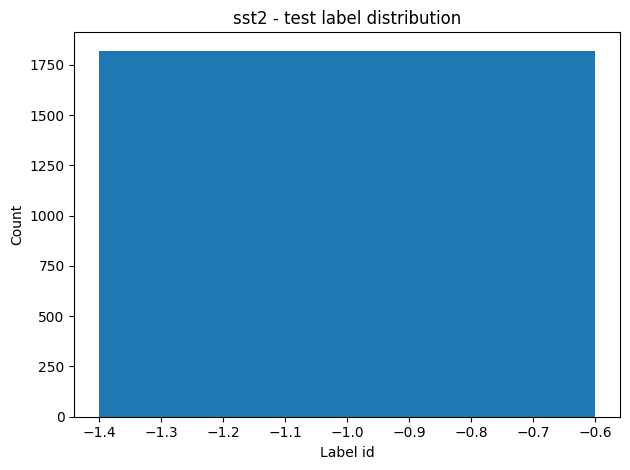

sentence - mean length: 19.23, median: 18.00, max: 56


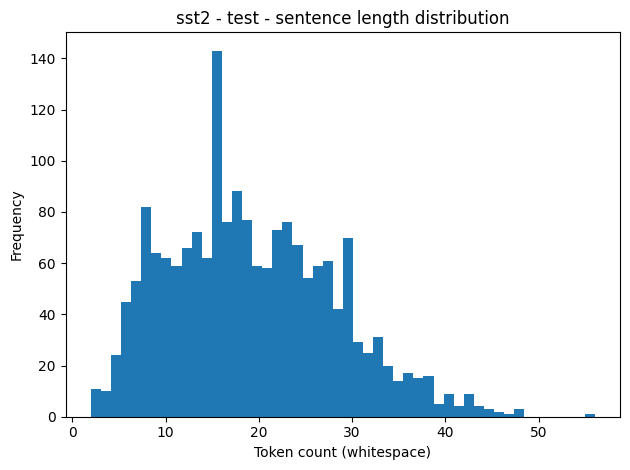


Sample examples:
Example 0:
  sentence: uneasy mishmash of styles and genres .
  label: -1
  idx: 0
Example 1:
  sentence: this film 's relationship to actual tension is the same as what christmas-tree flocking in a spray can is to actual snow : a poor -- if durable -- imitation .
  label: -1
  idx: 1
Example 2:
  sentence: by the end of no such thing the audience , like beatrice , has a watchful affection for the monster .
  label: -1
  idx: 2
--------------------------------------------------------------------------------
GLUE task: mrpc


mrpc/train-00000-of-00001.parquet:   0%|          | 0.00/649k [00:00<?, ?B/s]

mrpc/validation-00000-of-00001.parquet:   0%|          | 0.00/75.7k [00:00<?, ?B/s]

mrpc/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]


Split: train
Num examples: 3668
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': ClassLabel(names=['not_equivalent', 'equivalent']), 'idx': Value('int32')}
Label distribution: Counter({1: 2474, 0: 1194})


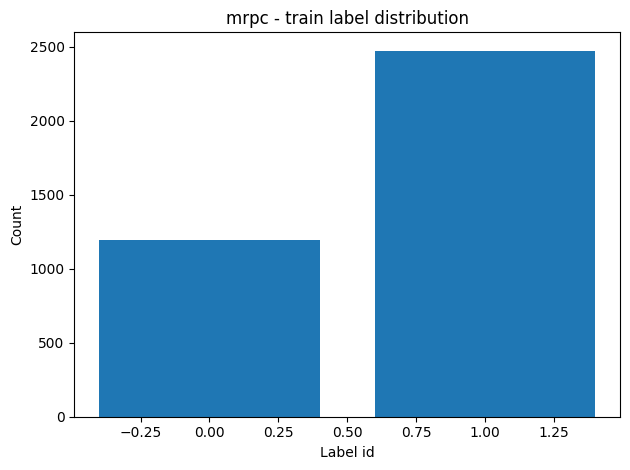

sentence1 - mean length: 21.94, median: 22.00, max: 39


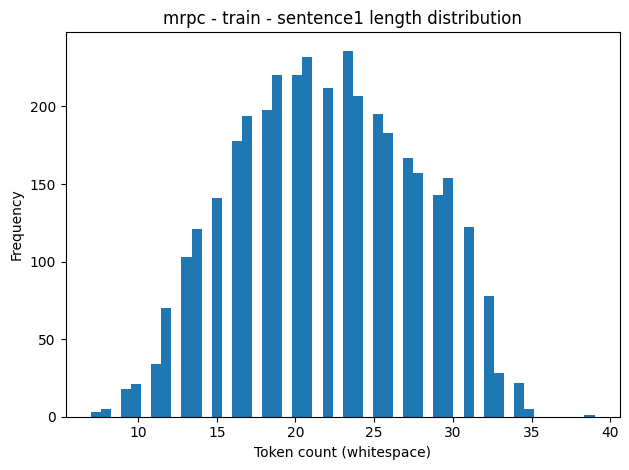

sentence2 - mean length: 21.95, median: 22.00, max: 42


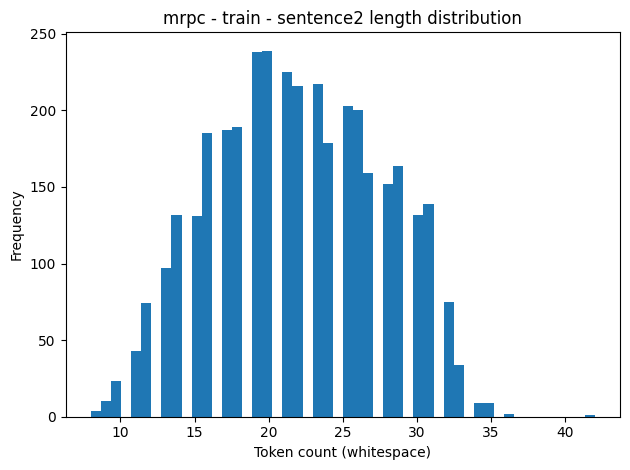


Sample examples:
Example 0:
  sentence1: Amrozi accused his brother , whom he called " the witness " , of deliberately distorting his evidence .
  sentence2: Referring to him as only " the witness " , Amrozi accused his brother of deliberately distorting his evidence .
  label: 1
  idx: 0
Example 1:
  sentence1: Yucaipa owned Dominick 's before selling the chain to Safeway in 1998 for $ 2.5 billion .
  sentence2: Yucaipa bought Dominick 's in 1995 for $ 693 million and sold it to Safeway for $ 1.8 billion in 1998 .
  label: 0
  idx: 1
Example 2:
  sentence1: They had published an advertisement on the Internet on June 10 , offering the cargo for sale , he added .
  sentence2: On June 10 , the ship 's owners had published an advertisement on the Internet , offering the explosives for sale .
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: validation
Num examples: 408
Features: {'sentence1': Value('string'), 'sentence2': Value('

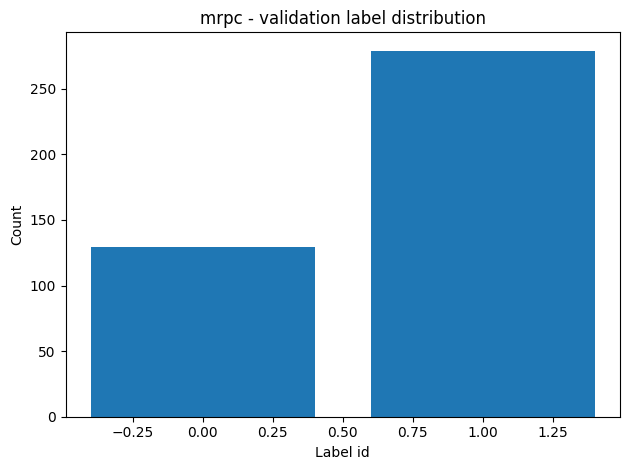

sentence1 - mean length: 22.34, median: 22.00, max: 35


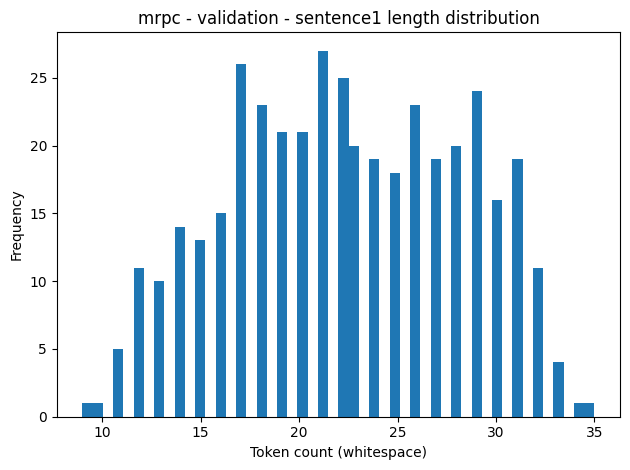

sentence2 - mean length: 21.70, median: 22.00, max: 34


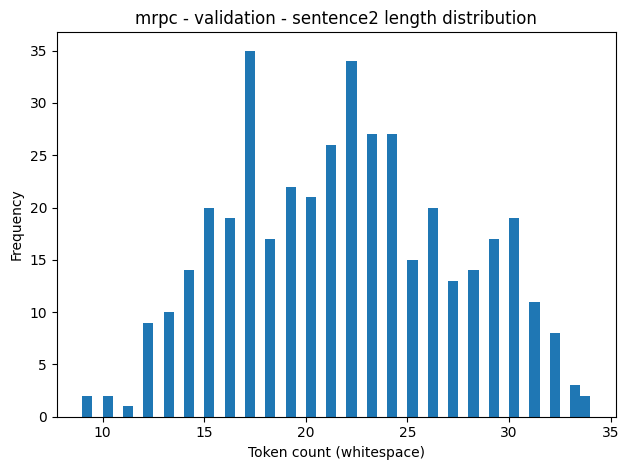


Sample examples:
Example 0:
  sentence1: He said the foodservice pie business doesn 't fit the company 's long-term growth strategy .
  sentence2: " The foodservice pie business does not fit our long-term growth strategy .
  label: 1
  idx: 9
Example 1:
  sentence1: Magnarelli said Racicot hated the Iraqi regime and looked forward to using his long years of training in the war .
  sentence2: His wife said he was " 100 percent behind George Bush " and looked forward to using his years of training in the war .
  label: 0
  idx: 18
Example 2:
  sentence1: The dollar was at 116.92 yen against the yen , flat on the session , and at 1.2891 against the Swiss franc , also flat .
  sentence2: The dollar was at 116.78 yen JPY = , virtually flat on the session , and at 1.2871 against the Swiss franc CHF = , down 0.1 percent .
  label: 0
  idx: 25
--------------------------------------------------------------------------------

Split: test
Num examples: 1725
Features: {'sentence1': Value('string'

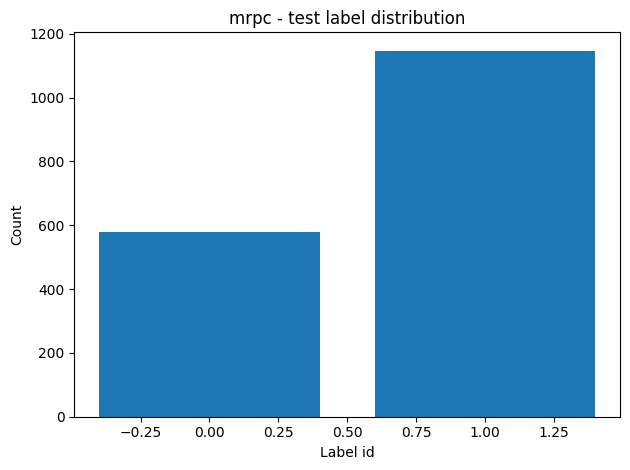

sentence1 - mean length: 21.73, median: 22.00, max: 36


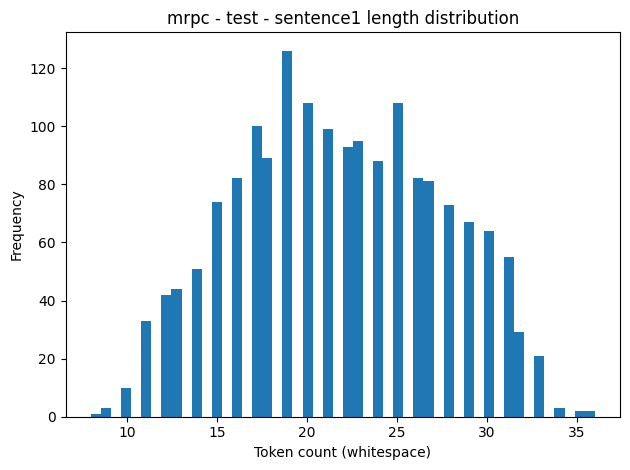

sentence2 - mean length: 21.77, median: 22.00, max: 35


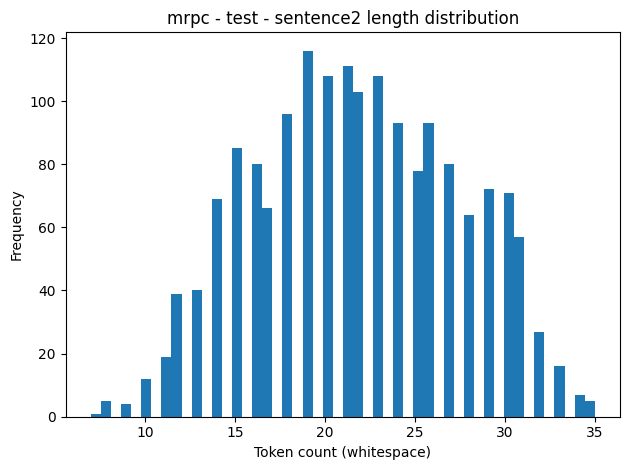


Sample examples:
Example 0:
  sentence1: PCCW 's chief operating officer , Mike Butcher , and Alex Arena , the chief financial officer , will report directly to Mr So .
  sentence2: Current Chief Operating Officer Mike Butcher and Group Chief Financial Officer Alex Arena will report to So .
  label: 1
  idx: 0
Example 1:
  sentence1: The world 's two largest automakers said their U.S. sales declined more than predicted last month as a late summer sales frenzy caused more of an industry backlash than expected .
  sentence2: Domestic sales at both GM and No. 2 Ford Motor Co. declined more than predicted as a late summer sales frenzy prompted a larger-than-expected industry backlash .
  label: 1
  idx: 1
Example 2:
  sentence1: According to the federal Centers for Disease Control and Prevention ( news - web sites ) , there were 19 reported cases of measles in the United States in 2002 .
  sentence2: The Centers for Disease Control and Prevention said there were 19 reported cases of measl

qqp/train-00000-of-00001.parquet:   0%|          | 0.00/33.6M [00:00<?, ?B/s]

qqp/validation-00000-of-00001.parquet:   0%|          | 0.00/3.73M [00:00<?, ?B/s]

qqp/test-00000-of-00001.parquet:   0%|          | 0.00/36.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40430 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/390965 [00:00<?, ? examples/s]


Split: train
Num examples: 363846
Features: {'question1': Value('string'), 'question2': Value('string'), 'label': ClassLabel(names=['not_duplicate', 'duplicate']), 'idx': Value('int32')}
Label distribution: Counter({0: 229468, 1: 134378})


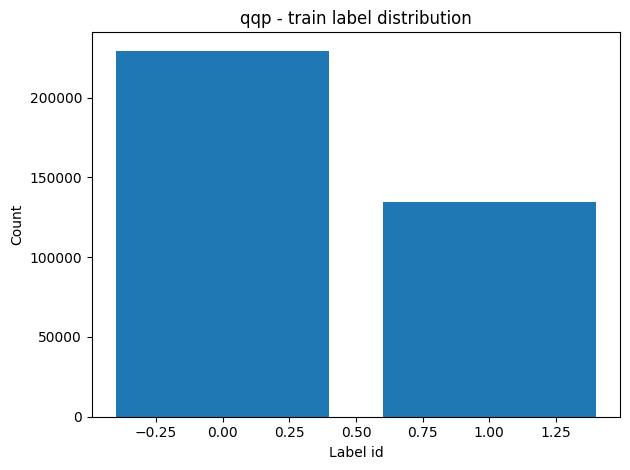


Sample examples:
Example 0:
  question1: How is the life of a math student? Could you describe your own experiences?
  question2: Which level of prepration is enough for the exam jlpt5?
  label: 0
  idx: 0
Example 1:
  question1: How do I control my horny emotions?
  question2: How do you control your horniness?
  label: 1
  idx: 1
Example 2:
  question1: What causes stool color to change to yellow?
  question2: What can cause stool to come out as little balls?
  label: 0
  idx: 2
--------------------------------------------------------------------------------

Split: validation
Num examples: 40430
Features: {'question1': Value('string'), 'question2': Value('string'), 'label': ClassLabel(names=['not_duplicate', 'duplicate']), 'idx': Value('int32')}
Label distribution: Counter({0: 25545, 1: 14885})


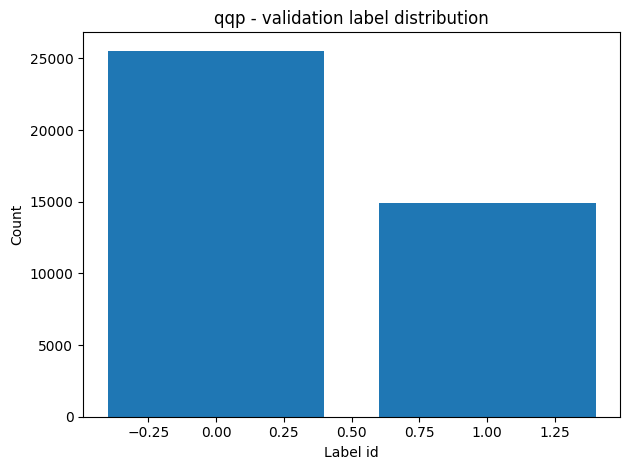


Sample examples:
Example 0:
  question1: Why are African-Americans so beautiful?
  question2: Why are hispanics so beautiful?
  label: 0
  idx: 0
Example 1:
  question1: I want to pursue PhD in Computer Science about social network,what is the open problem in social networks?
  question2: I handle social media for a non-profit. Should I start going to social media networking events? Are there any good ones in the bay area?
  label: 0
  idx: 1
Example 2:
  question1: Is there a reason why we should travel alone?
  question2: What are some reasons to travel alone?
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: test
Num examples: 390965
Features: {'question1': Value('string'), 'question2': Value('string'), 'label': ClassLabel(names=['not_duplicate', 'duplicate']), 'idx': Value('int32')}
Label distribution: Counter({-1: 390965})


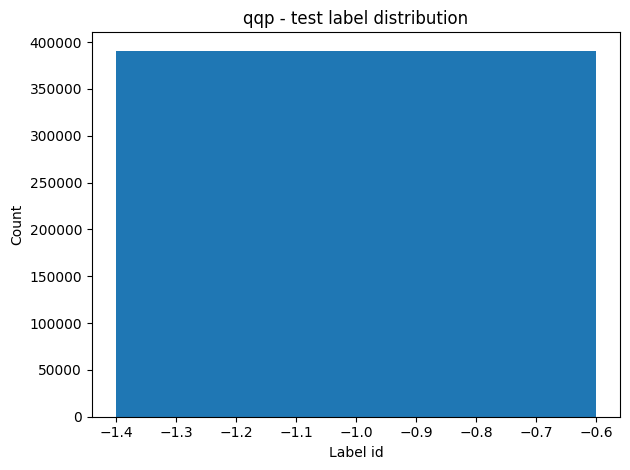


Sample examples:
Example 0:
  question1: Would the idea of Trump and Putin in bed together scare you, given the geopolitical implications?
  question2: Do you think that if Donald Trump were elected President, he would be able to restore relations with Putin and Russia as he said he could, based on the rocky relationship Putin had with Obama and Bush...
  label: -1
  idx: 0
Example 1:
  question1: What are the top ten Consumer-to-Consumer E-commerce online?
  question2: What are the top ten Consumer-to-Business E-commerce online?
  label: -1
  idx: 1
Example 2:
  question1: Why don't people simply 'Google' instead of asking questions on Quora?
  question2: Why do people ask Quora questions instead of just searching google?
  label: -1
  idx: 2
--------------------------------------------------------------------------------
GLUE task: stsb


stsb/train-00000-of-00001.parquet:   0%|          | 0.00/502k [00:00<?, ?B/s]

stsb/validation-00000-of-00001.parquet:   0%|          | 0.00/151k [00:00<?, ?B/s]

stsb/test-00000-of-00001.parquet:   0%|          | 0.00/114k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]


Split: train
Num examples: 5749
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': Value('float32'), 'idx': Value('int32')}
sentence1 - mean length: 9.95, median: 8.00, max: 56


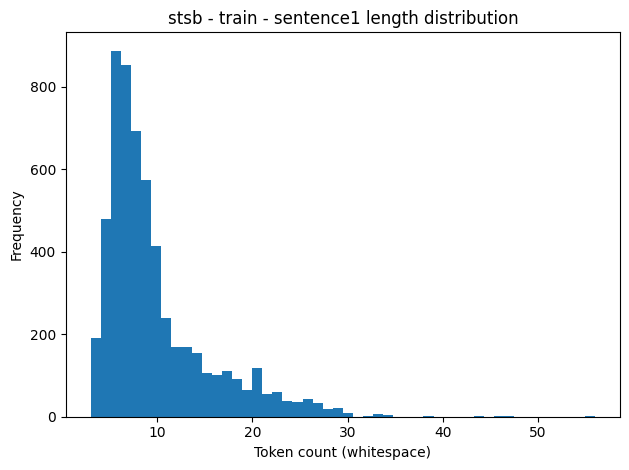

sentence2 - mean length: 9.94, median: 8.00, max: 48


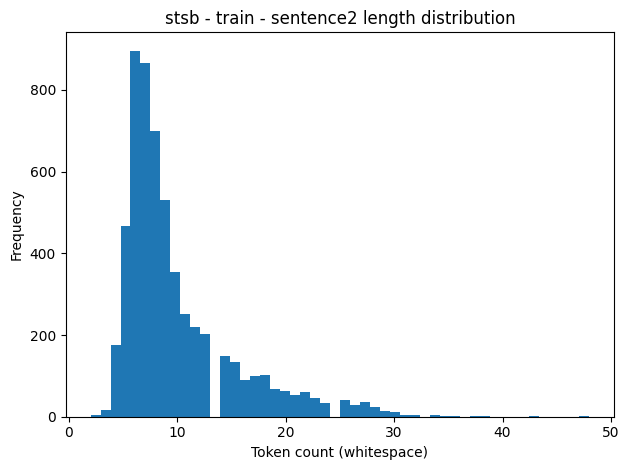


Sample examples:
Example 0:
  sentence1: A plane is taking off.
  sentence2: An air plane is taking off.
  label: 5.0
  idx: 0
Example 1:
  sentence1: A man is playing a large flute.
  sentence2: A man is playing a flute.
  label: 3.799999952316284
  idx: 1
Example 2:
  sentence1: A man is spreading shreded cheese on a pizza.
  sentence2: A man is spreading shredded cheese on an uncooked pizza.
  label: 3.799999952316284
  idx: 2
--------------------------------------------------------------------------------

Split: validation
Num examples: 1500
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': Value('float32'), 'idx': Value('int32')}
sentence1 - mean length: 11.42, median: 10.00, max: 29


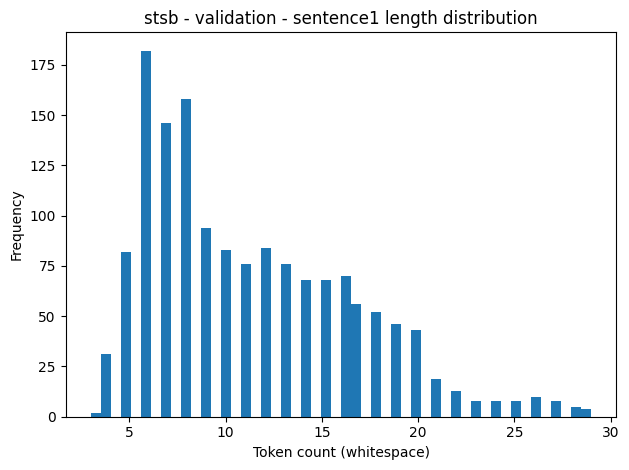

sentence2 - mean length: 11.34, median: 10.00, max: 29


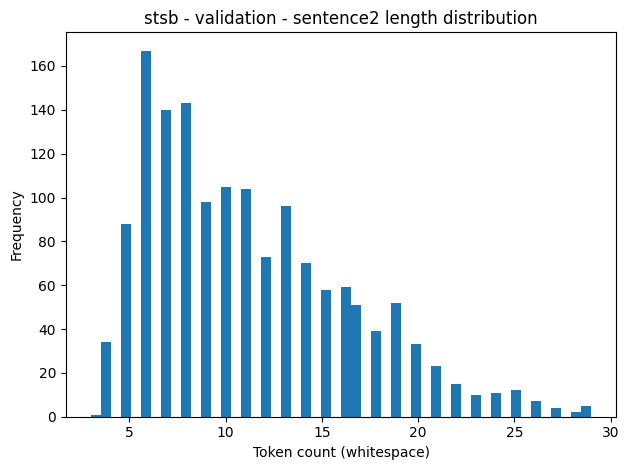


Sample examples:
Example 0:
  sentence1: A man with a hard hat is dancing.
  sentence2: A man wearing a hard hat is dancing.
  label: 5.0
  idx: 0
Example 1:
  sentence1: A young child is riding a horse.
  sentence2: A child is riding a horse.
  label: 4.75
  idx: 1
Example 2:
  sentence1: A man is feeding a mouse to a snake.
  sentence2: The man is feeding a mouse to the snake.
  label: 5.0
  idx: 2
--------------------------------------------------------------------------------

Split: test
Num examples: 1379
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': Value('float32'), 'idx': Value('int32')}
sentence1 - mean length: 9.82, median: 8.00, max: 30


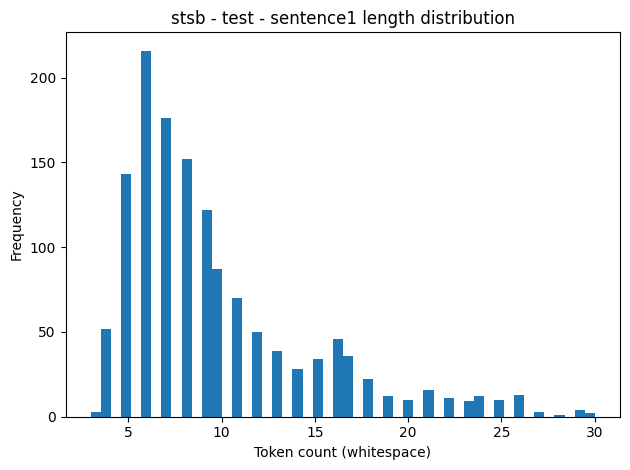

sentence2 - mean length: 9.80, median: 8.00, max: 30


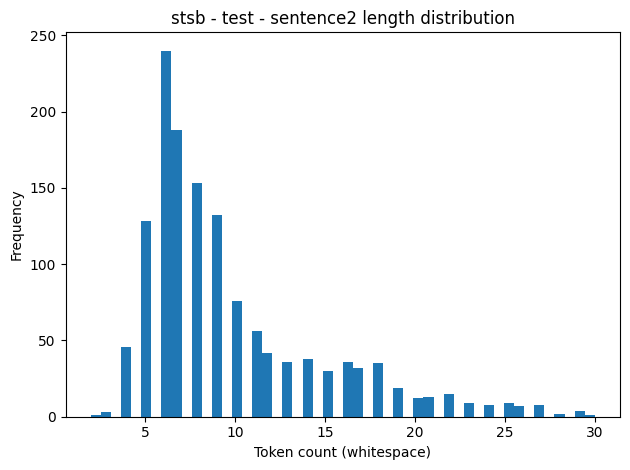


Sample examples:
Example 0:
  sentence1: A girl is styling her hair.
  sentence2: A girl is brushing her hair.
  label: -1.0
  idx: 0
Example 1:
  sentence1: A group of men play soccer on the beach.
  sentence2: A group of boys are playing soccer on the beach.
  label: -1.0
  idx: 1
Example 2:
  sentence1: One woman is measuring another woman's ankle.
  sentence2: A woman measures another woman's ankle.
  label: -1.0
  idx: 2
--------------------------------------------------------------------------------
GLUE task: mnli


mnli/train-00000-of-00001.parquet:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

mnli/validation_matched-00000-of-00001.p(…):   0%|          | 0.00/1.21M [00:00<?, ?B/s]

mnli/validation_mismatched-00000-of-0000(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

mnli/test_matched-00000-of-00001.parquet:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

...

Generating validation_matched split:   0%|          | 0/9815 [00:00<?, ? examples/s]

Generating validation_mismatched split:   0%|          | 0/9832 [00:00<?, ? examples/s]

Generating test_matched split:   0%|          | 0/9796 [00:00<?, ? examples/s]

Generating test_mismatched split:   0%|          | 0/9847 [00:00<?, ? examples/s]


Split: train
Num examples: 392702
Features: {'premise': Value('string'), 'hypothesis': Value('string'), 'label': ClassLabel(names=['entailment', 'neutral', 'contradiction']), 'idx': Value('int32')}
Label distribution: Counter({2: 130903, 1: 130900, 0: 130899})


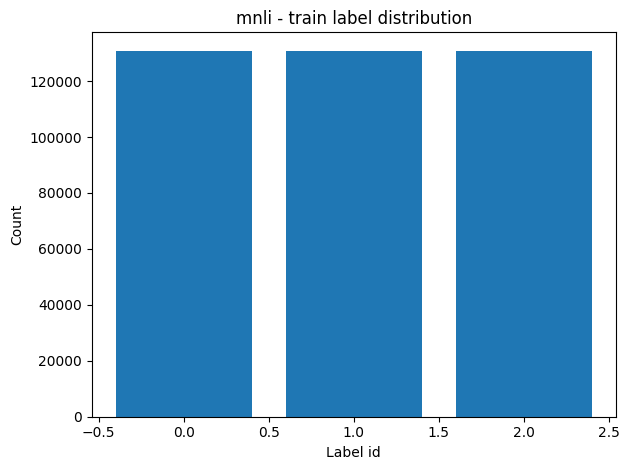

premise - mean length: 19.81, median: 17.00, max: 382


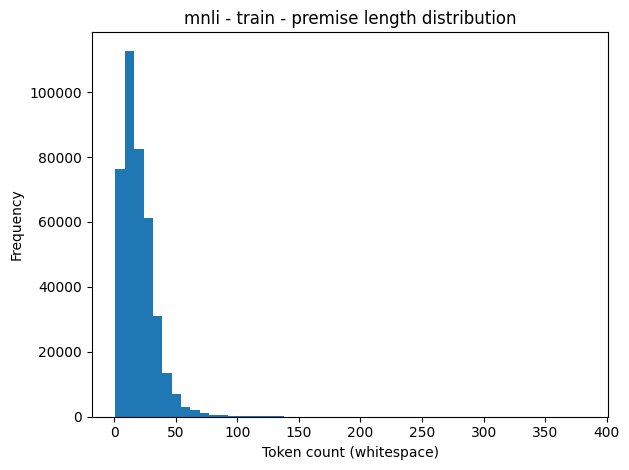

hypothesis - mean length: 9.97, median: 9.00, max: 69


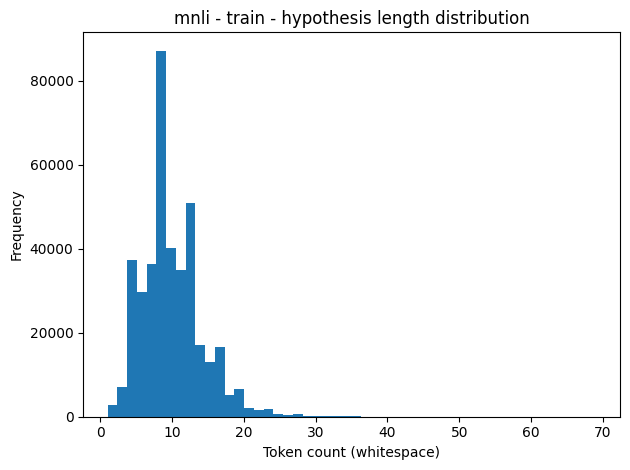


Sample examples:
Example 0:
  premise: Conceptually cream skimming has two basic dimensions - product and geography.
  hypothesis: Product and geography are what make cream skimming work. 
  label: 1
  idx: 0
Example 1:
  premise: you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then ...
  hypothesis: You lose the things to the following level if the people recall.
  label: 0
  idx: 1
Example 2:
  premise: One of our number will carry out your instructions minutely.
  hypothesis: A member of my team will execute your orders with immense precision.
  label: 0
  idx: 2
--------------------------------------------------------------------------------

Split: validation_matched
Num examples: 9815
Features: {'premise': Value('string'), 'hypothesis': Value('string'), 'label': ClassLabel(names=['entailment', 'neutral', 'contradiction']), 'idx': Valu

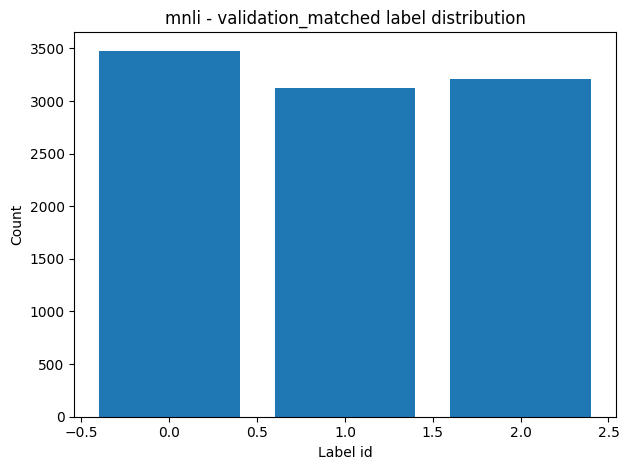

premise - mean length: 19.27, median: 16.00, max: 196


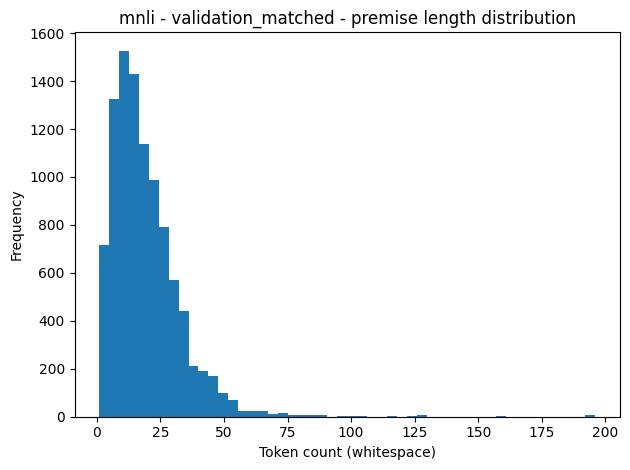

hypothesis - mean length: 9.92, median: 9.00, max: 46


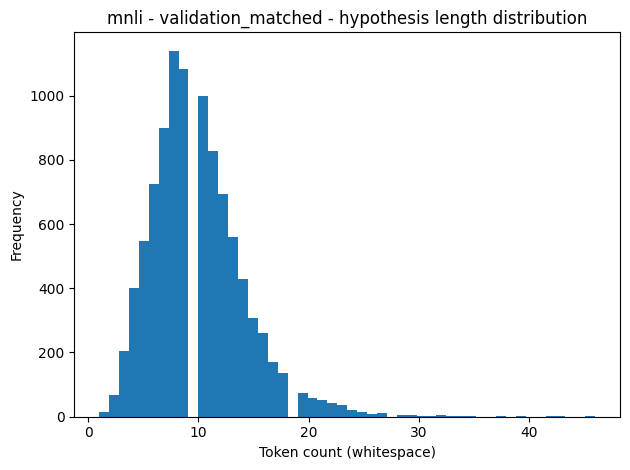


Sample examples:
Example 0:
  premise: The new rights are nice enough
  hypothesis: Everyone really likes the newest benefits 
  label: 1
  idx: 0
Example 1:
  premise: This site includes a list of all award winners and a searchable database of Government Executive articles.
  hypothesis: The Government Executive articles housed on the website are not able to be searched.
  label: 2
  idx: 1
Example 2:
  premise: uh i don't know i i have mixed emotions about him uh sometimes i like him but at the same times i love to see somebody beat him
  hypothesis: I like him for the most part, but would still enjoy seeing someone beat him.
  label: 0
  idx: 2
--------------------------------------------------------------------------------

Split: validation_mismatched
Num examples: 9832
Features: {'premise': Value('string'), 'hypothesis': Value('string'), 'label': ClassLabel(names=['entailment', 'neutral', 'contradiction']), 'idx': Value('int32')}
Label distribution: Counter({0: 3463, 2: 3240, 1:

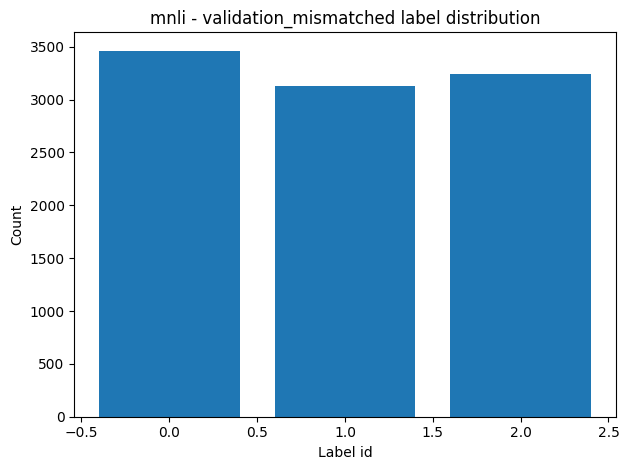

premise - mean length: 19.64, median: 17.00, max: 129


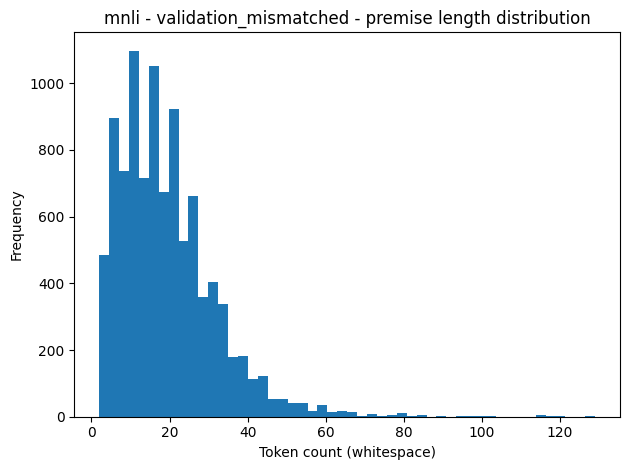

hypothesis - mean length: 10.83, median: 10.00, max: 53


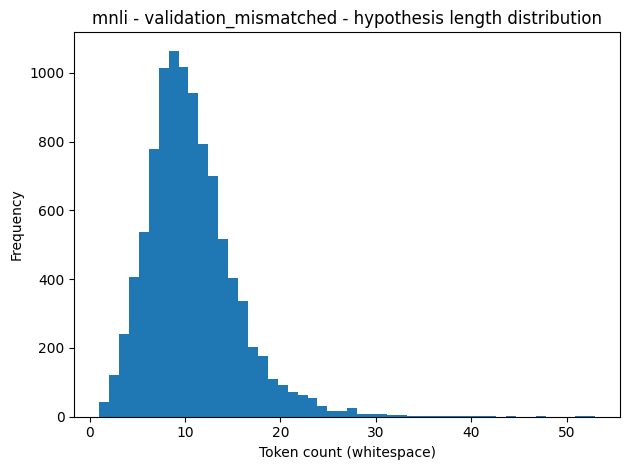


Sample examples:
Example 0:
  premise: Your contribution helped make it possible for us to provide our students with a quality education.
  hypothesis: Your contributions were of no help with our students' education.
  label: 2
  idx: 0
Example 1:
  premise: The answer has nothing to do with their cause, however, but with the simple fact that dictionaries are not exercises in bi-unique substitutability; in other words, if one of the senses of run is `oper...
  hypothesis: Dictionaries are indeed exercises in bi-unique substitutability.
  label: 2
  idx: 1
Example 2:
  premise:  We serve a classic Tuscan meal that includes a Florentine terrine made with dick and chicken livers.
  hypothesis: We serve a meal of Florentine terrine.
  label: 0
  idx: 2
--------------------------------------------------------------------------------

Split: test_matched
Num examples: 9796
Features: {'premise': Value('string'), 'hypothesis': Value('string'), 'label': ClassLabel(names=['entailment', 'neutral

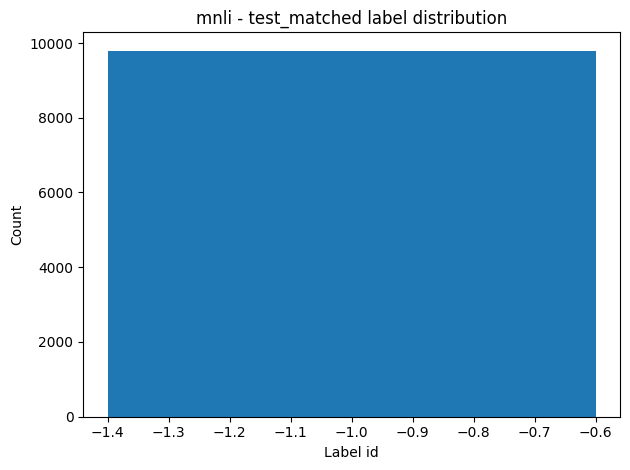

premise - mean length: 19.65, median: 17.00, max: 208


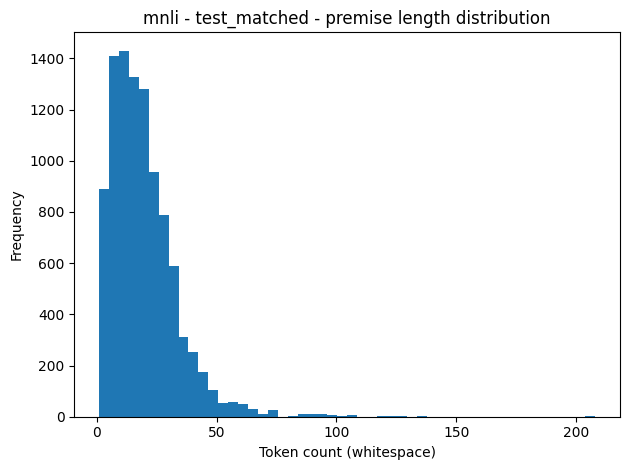

hypothesis - mean length: 9.89, median: 9.00, max: 50


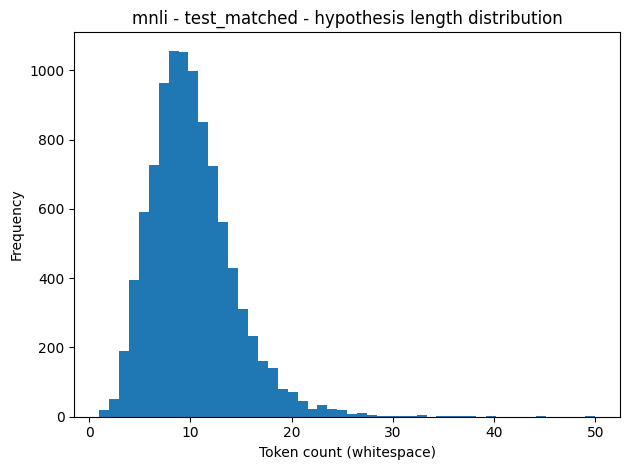


Sample examples:
Example 0:
  premise: Hierbas, ans seco, ans dulce, and frigola are just a few names worth keeping a look-out for.
  hypothesis: Hierbas is a name worth looking out for.
  label: -1
  idx: 0
Example 1:
  premise: The extent of the behavioral effects would depend in part on the structure of the individual account program and any limits on accessing the funds.
  hypothesis: Many people would be very unhappy to loose control over their own money.
  label: -1
  idx: 1
Example 2:
  premise: Timely access to information is in the best interests of both GAO and the agencies.
  hypothesis: It is in everyone's best interest to have access to information in a timely manner.
  label: -1
  idx: 2
--------------------------------------------------------------------------------

Split: test_mismatched
Num examples: 9847
Features: {'premise': Value('string'), 'hypothesis': Value('string'), 'label': ClassLabel(names=['entailment', 'neutral', 'contradiction']), 'idx': Value('int32')}


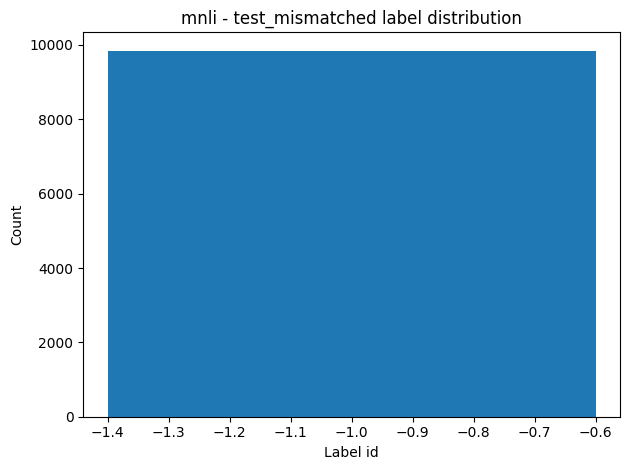

premise - mean length: 19.56, median: 18.00, max: 176


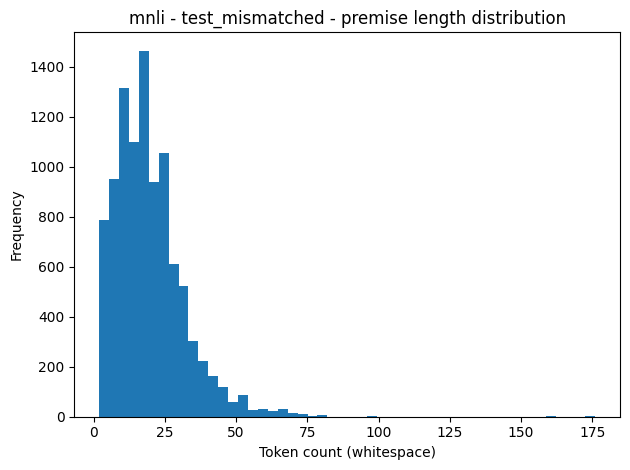

hypothesis - mean length: 10.81, median: 10.00, max: 52


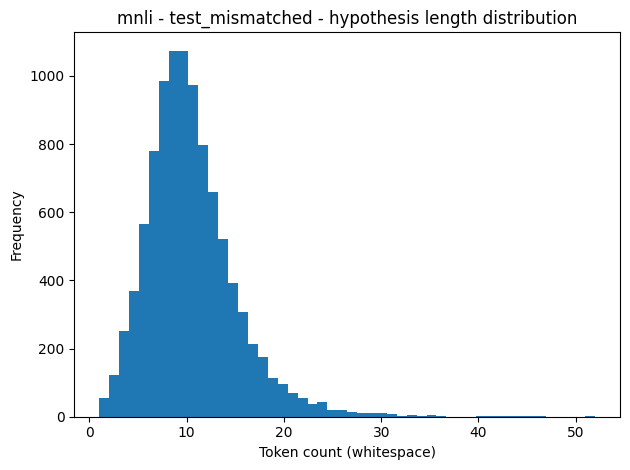


Sample examples:
Example 0:
  premise: What have you decided, what are you going to do?
  hypothesis: So what's your decision?
  label: -1
  idx: 0
Example 1:
  premise: Women's clothing is characterized by great diversity in styles and short production runs.
  hypothesis: Men's clothing typically has the most stylistic diversity unlike the blandness of women's fashion.
  label: -1
  idx: 1
Example 2:
  premise: Reports from two flight attendants in the coach cabin, Betty Ong and Madeline Amy Sweeney, tell us most of what we know about how the hijacking happened.
  hypothesis: The report on the hijacking was over five hundred pages long.
  label: -1
  idx: 2
--------------------------------------------------------------------------------
GLUE task: qnli


qnli/train-00000-of-00001.parquet:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

qnli/validation-00000-of-00001.parquet:   0%|          | 0.00/872k [00:00<?, ?B/s]

qnli/test-00000-of-00001.parquet:   0%|          | 0.00/877k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/104743 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5463 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5463 [00:00<?, ? examples/s]


Split: train
Num examples: 104743
Features: {'question': Value('string'), 'sentence': Value('string'), 'label': ClassLabel(names=['entailment', 'not_entailment']), 'idx': Value('int32')}
Label distribution: Counter({0: 52377, 1: 52366})


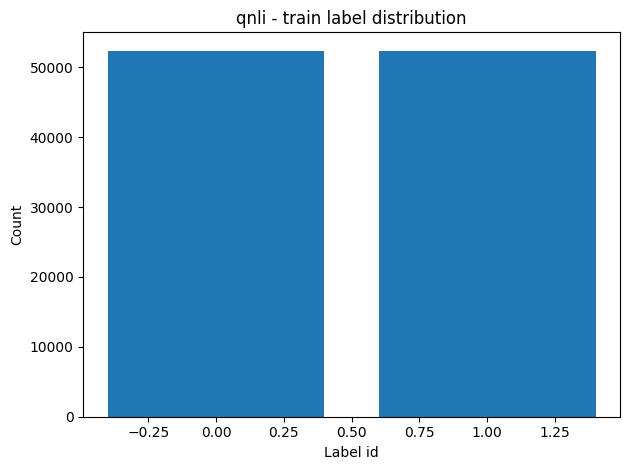

question - mean length: 9.93, median: 9.00, max: 40


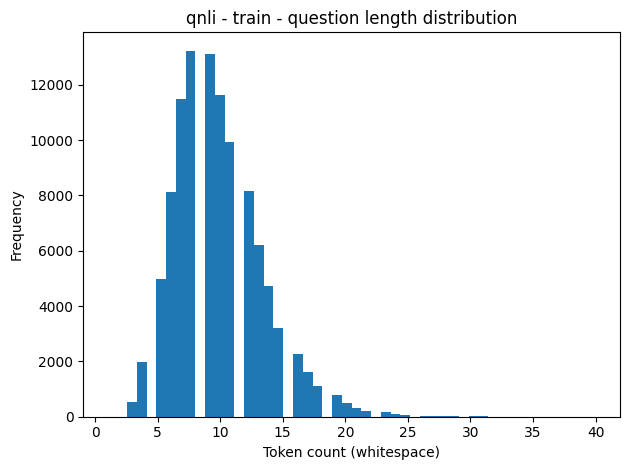

sentence - mean length: 26.52, median: 24.00, max: 337


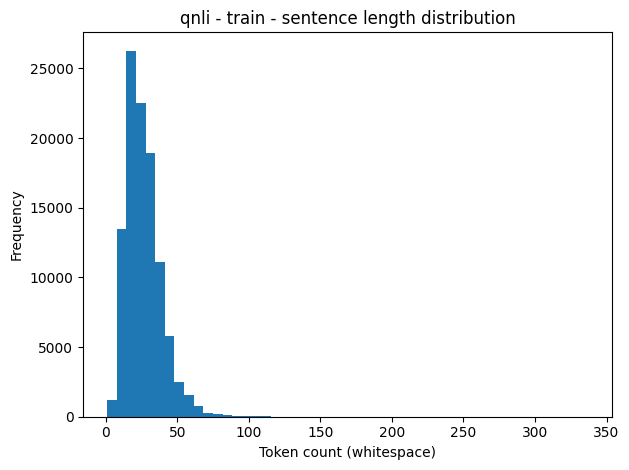


Sample examples:
Example 0:
  question: When did the third Digimon series begin?
  sentence: Unlike the two seasons before it and most of the seasons that followed, Digimon Tamers takes a darker and more realistic approach to its story featuring Digimon who do not reincarnate after their deat...
  label: 1
  idx: 0
Example 1:
  question: Which missile batteries often have individual launchers several kilometres from one another?
  sentence: When MANPADS is operated by specialists, batteries may have several dozen teams deploying separately in small sections; self-propelled air defence guns may deploy in pairs.
  label: 1
  idx: 1
Example 2:
  question: What two things does Popper argue Tarski's theory involves in an evaluation of truth?
  sentence: He bases this interpretation on the fact that examples such as the one described above refer to two things: assertions and the facts to which they refer.
  label: 0
  idx: 2
------------------------------------------------------------------

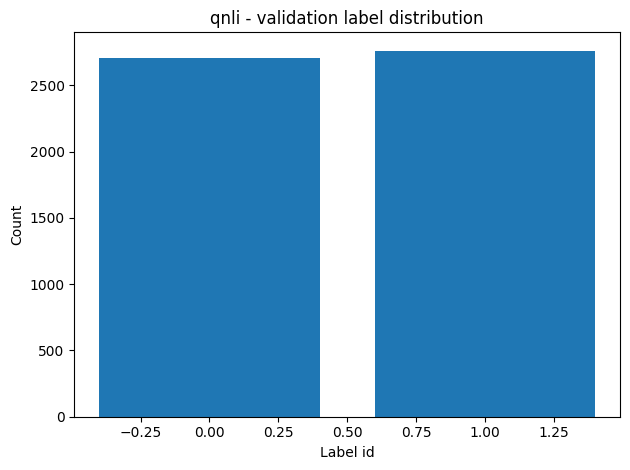

question - mean length: 10.04, median: 10.00, max: 33


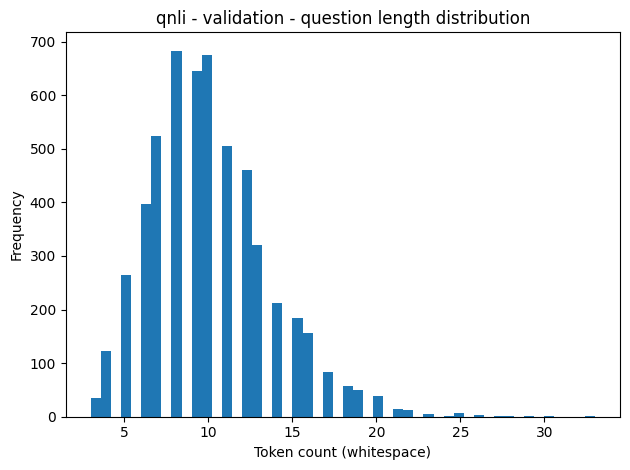

sentence - mean length: 27.59, median: 25.00, max: 153


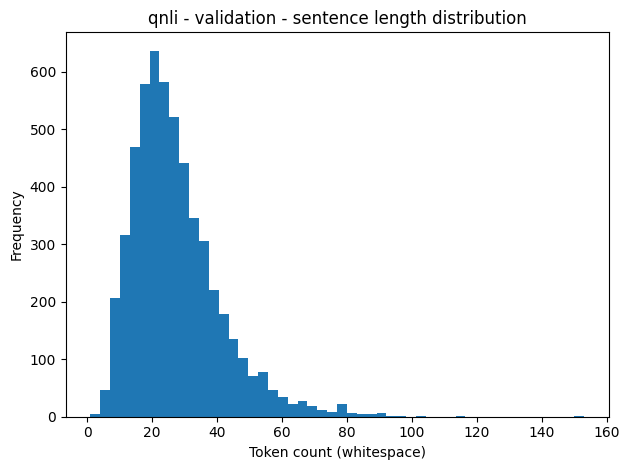


Sample examples:
Example 0:
  question: What came into force after the new constitution was herald?
  sentence: As of that day, the new constitution heralding the Second Republic came into force.
  label: 0
  idx: 0
Example 1:
  question: What is the first major city in the stream of the Rhine?
  sentence: The most important tributaries in this area are the Ill below of Strasbourg, the Neckar in Mannheim and the Main across from Mainz.
  label: 1
  idx: 1
Example 2:
  question: What is the minimum required if you want to teach in Canada?
  sentence: In most provinces a second Bachelor's Degree such as a Bachelor of Education is required to become a qualified teacher.
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: test
Num examples: 5463
Features: {'question': Value('string'), 'sentence': Value('string'), 'label': ClassLabel(names=['entailment', 'not_entailment']), 'idx': Value('int32')}
Label distribution: Counter({-1: 5463

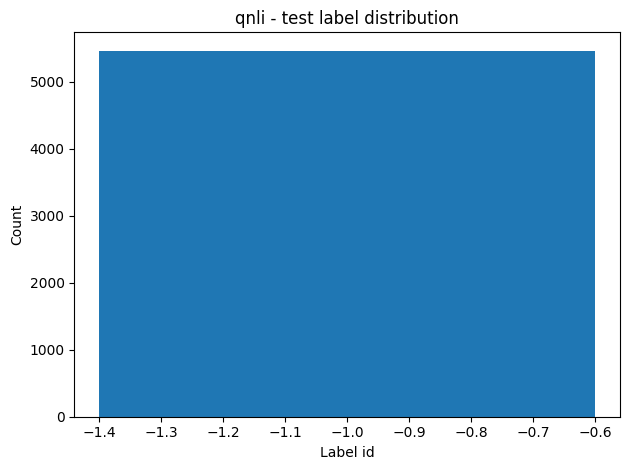

question - mean length: 9.95, median: 10.00, max: 33


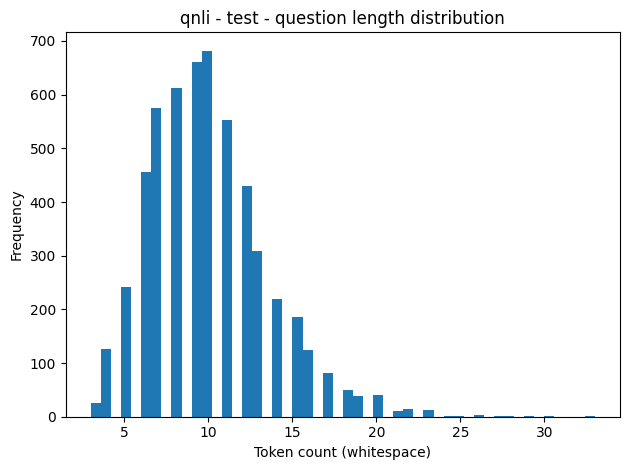

sentence - mean length: 27.52, median: 25.00, max: 229


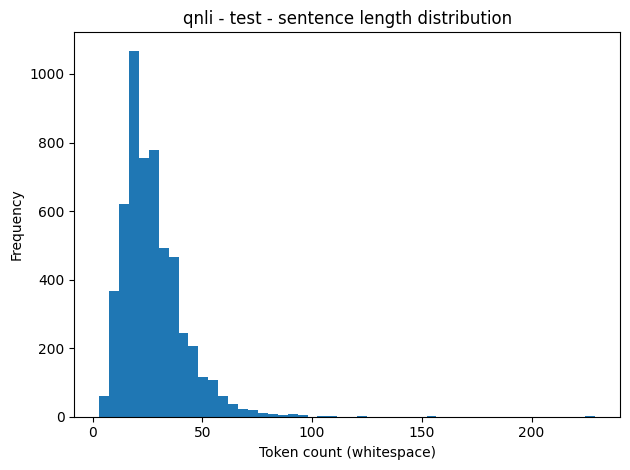


Sample examples:
Example 0:
  question: What organization is devoted to Jihad against Israel?
  sentence: For some decades prior to the First Palestine Intifada in 1987, the Muslim Brotherhood in Palestine took a "quiescent" stance towards Israel, focusing on preaching, education and social services, and ...
  label: -1
  idx: 0
Example 1:
  question: In what century was the Yarrow-Schlick-Tweedy balancing system used?
  sentence: In the late 19th century, the Yarrow-Schlick-Tweedy balancing 'system' was used on some marine triple expansion engines.
  label: -1
  idx: 1
Example 2:
  question: The largest brand of what store in the UK is located in Kingston Park?
  sentence: Close to Newcastle, the largest indoor shopping centre in Europe, the MetroCentre, is located in Gateshead.
  label: -1
  idx: 2
--------------------------------------------------------------------------------
GLUE task: rte


rte/train-00000-of-00001.parquet:   0%|          | 0.00/584k [00:00<?, ?B/s]

rte/validation-00000-of-00001.parquet:   0%|          | 0.00/69.0k [00:00<?, ?B/s]

rte/test-00000-of-00001.parquet:   0%|          | 0.00/621k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2490 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/277 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3000 [00:00<?, ? examples/s]


Split: train
Num examples: 2490
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': ClassLabel(names=['entailment', 'not_entailment']), 'idx': Value('int32')}
Label distribution: Counter({0: 1249, 1: 1241})


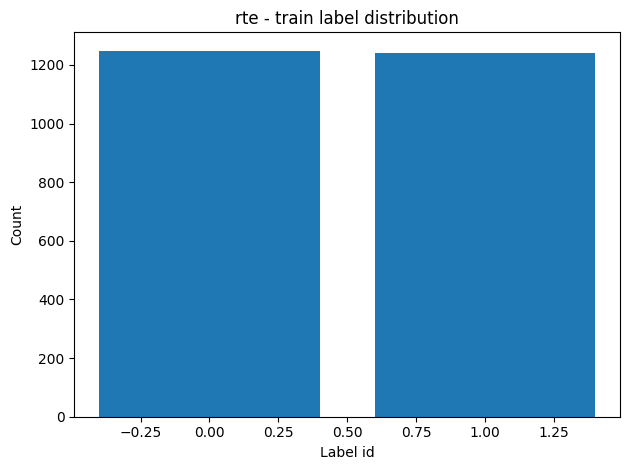


Sample examples:
Example 0:
  sentence1: No Weapons of Mass Destruction Found in Iraq Yet.
  sentence2: Weapons of Mass Destruction Found in Iraq.
  label: 1
  idx: 0
Example 1:
  sentence1: A place of sorrow, after Pope John Paul II died, became a place of celebration, as Roman Catholic faithful gathered in downtown Chicago to mark the installation of new Pope Benedict XVI.
  sentence2: Pope Benedict XVI is the new leader of the Roman Catholic Church.
  label: 0
  idx: 1
Example 2:
  sentence1: Herceptin was already approved to treat the sickest breast cancer patients, and the company said, Monday, it will discuss with federal regulators the possibility of prescribing the drug for more breas...
  sentence2: Herceptin can be used to treat breast cancer.
  label: 0
  idx: 2
--------------------------------------------------------------------------------

Split: validation
Num examples: 277
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': ClassLabel(names=

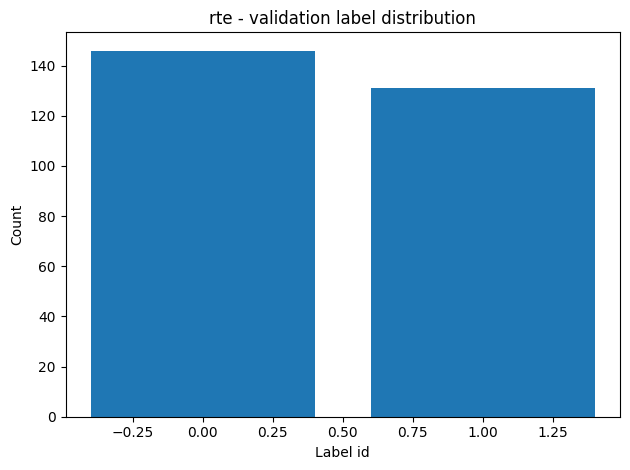


Sample examples:
Example 0:
  sentence1: Dana Reeve, the widow of the actor Christopher Reeve, has died of lung cancer at age 44, according to the Christopher Reeve Foundation.
  sentence2: Christopher Reeve had an accident.
  label: 1
  idx: 0
Example 1:
  sentence1: Yet, we now are discovering that antibiotics are losing their effectiveness against illness. Disease-causing bacteria are mutating faster than we can come up with new antibiotics to fight the new vari...
  sentence2: Bacteria is winning the war against antibiotics.
  label: 0
  idx: 1
Example 2:
  sentence1: Cairo is now home to some 15 million people - a burgeoning population that produces approximately 10,000 tonnes of rubbish per day, putting an enormous strain on public services. In the past 10 years,...
  sentence2: 15 million tonnes of rubbish are produced daily in Cairo.
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: test
Num examples: 3000
Features: {'

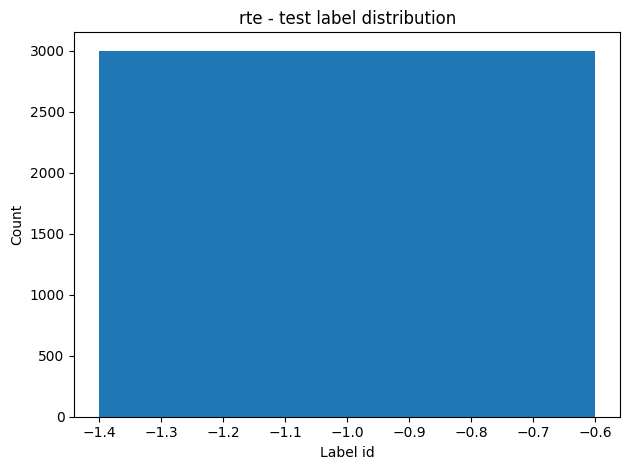


Sample examples:
Example 0:
  sentence1: Mangla was summoned after Madhumita's sister Nidhi Shukla, who was the first witness in the case.
  sentence2: Shukla is related to Mangla.
  label: -1
  idx: 0
Example 1:
  sentence1: Authorities in Brazil say that more than 200 people are being held hostage in a prison in the country's remote, Amazonian-jungle state of Rondonia.
  sentence2: Authorities in Brazil hold 200 people as hostage.
  label: -1
  idx: 1
Example 2:
  sentence1: A mercenary group faithful to the warmongering policy of former Somozist colonel Enrique Bermudez attacked an IFA truck belonging to the interior ministry at 0900 on 26 March in El Jicote, wounded and...
  sentence2: An interior ministry worker was killed by a mercenary group.
  label: -1
  idx: 2
--------------------------------------------------------------------------------
GLUE task: wnli


wnli/train-00000-of-00001.parquet:   0%|          | 0.00/38.8k [00:00<?, ?B/s]

wnli/validation-00000-of-00001.parquet:   0%|          | 0.00/11.1k [00:00<?, ?B/s]

wnli/test-00000-of-00001.parquet:   0%|          | 0.00/13.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/635 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/71 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/146 [00:00<?, ? examples/s]


Split: train
Num examples: 635
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': ClassLabel(names=['not_entailment', 'entailment']), 'idx': Value('int32')}
Label distribution: Counter({0: 323, 1: 312})


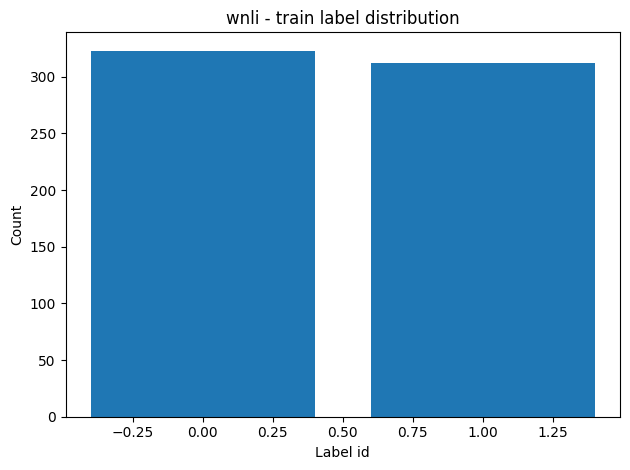


Sample examples:
Example 0:
  sentence1: I stuck a pin through a carrot. When I pulled the pin out, it had a hole.
  sentence2: The carrot had a hole.
  label: 1
  idx: 0
Example 1:
  sentence1: John couldn't see the stage with Billy in front of him because he is so short.
  sentence2: John is so short.
  label: 1
  idx: 1
Example 2:
  sentence1: The police arrested all of the gang members. They were trying to stop the drug trade in the neighborhood.
  sentence2: The police were trying to stop the drug trade in the neighborhood.
  label: 1
  idx: 2
--------------------------------------------------------------------------------

Split: validation
Num examples: 71
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': ClassLabel(names=['not_entailment', 'entailment']), 'idx': Value('int32')}
Label distribution: Counter({0: 40, 1: 31})


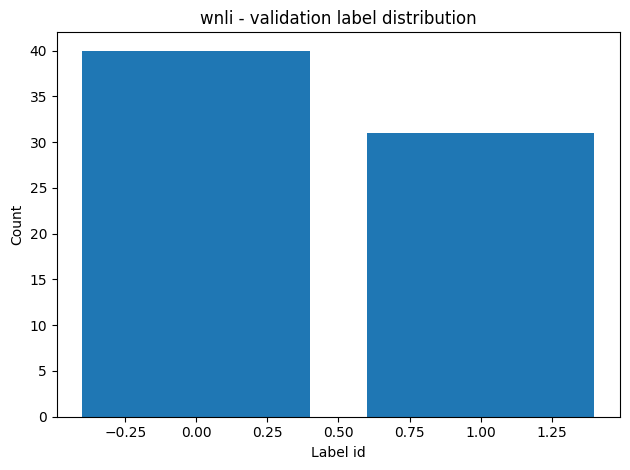


Sample examples:
Example 0:
  sentence1: The drain is clogged with hair. It has to be cleaned.
  sentence2: The hair has to be cleaned.
  label: 0
  idx: 0
Example 1:
  sentence1: Jane knocked on Susan's door but she did not answer.
  sentence2: Susan did not answer.
  label: 1
  idx: 1
Example 2:
  sentence1: Beth didn't get angry with Sally, who had cut her off, because she stopped and counted to ten.
  sentence2: Sally stopped and counted to ten.
  label: 0
  idx: 2
--------------------------------------------------------------------------------

Split: test
Num examples: 146
Features: {'sentence1': Value('string'), 'sentence2': Value('string'), 'label': ClassLabel(names=['not_entailment', 'entailment']), 'idx': Value('int32')}
Label distribution: Counter({-1: 146})


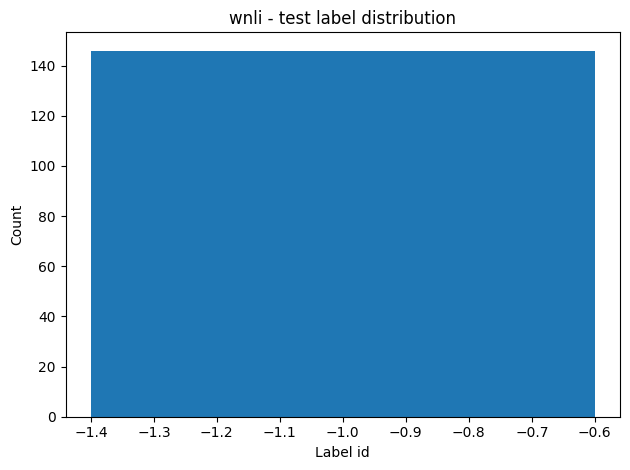


Sample examples:
Example 0:
  sentence1: Maude and Dora had seen the trains rushing across the prairie, with long, rolling puffs of black smoke streaming back from the engine. Their roars and their wild, clear whistles could be heard from fa...
  sentence2: Horses ran away when Maude and Dora came in sight.
  label: -1
  idx: 0
Example 1:
  sentence1: Maude and Dora had seen the trains rushing across the prairie, with long, rolling puffs of black smoke streaming back from the engine. Their roars and their wild, clear whistles could be heard from fa...
  sentence2: Horses ran away when the trains came in sight.
  label: -1
  idx: 1
Example 2:
  sentence1: Maude and Dora had seen the trains rushing across the prairie, with long, rolling puffs of black smoke streaming back from the engine. Their roars and their wild, clear whistles could be heard from fa...
  sentence2: Horses ran away when the puffs came in sight.
  label: -1
  idx: 2
----------------------------------------------------

ax/test-00000-of-00001.parquet:   0%|          | 0.00/80.8k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1104 [00:00<?, ? examples/s]


Split: test
Num examples: 1104
Features: {'premise': Value('string'), 'hypothesis': Value('string'), 'label': ClassLabel(names=['entailment', 'neutral', 'contradiction']), 'idx': Value('int32')}
Label distribution: Counter({-1: 1104})


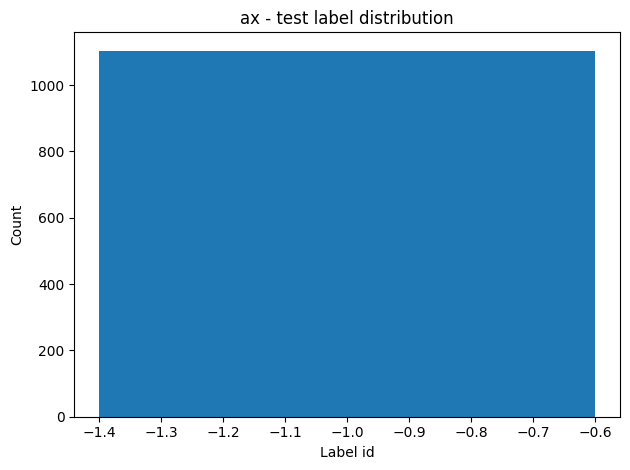

premise - mean length: 16.06, median: 14.00, max: 44


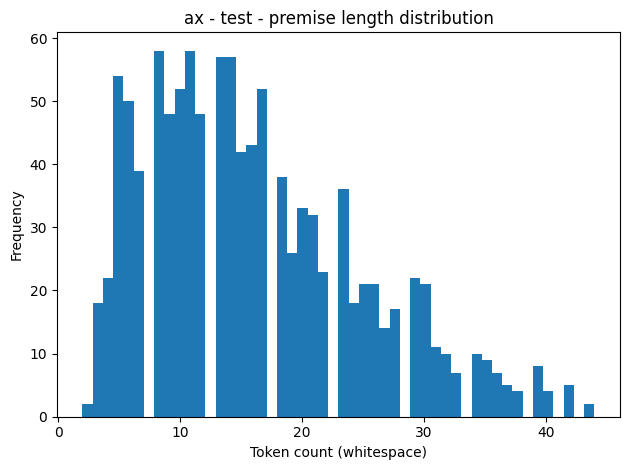

hypothesis - mean length: 16.06, median: 14.00, max: 44


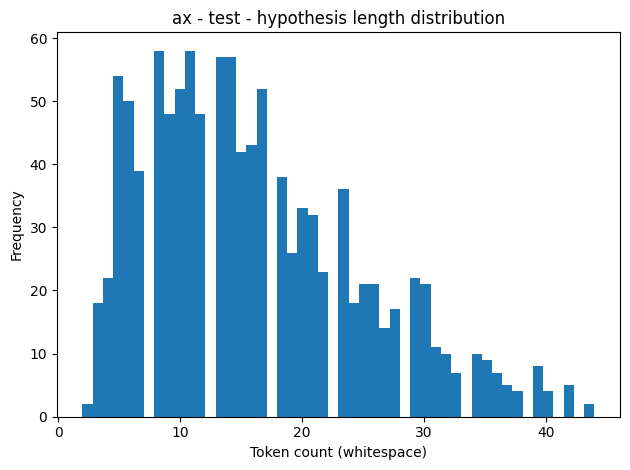


Sample examples:
Example 0:
  premise: The cat sat on the mat.
  hypothesis: The cat did not sit on the mat.
  label: -1
  idx: 0
Example 1:
  premise: The cat did not sit on the mat.
  hypothesis: The cat sat on the mat.
  label: -1
  idx: 1
Example 2:
  premise: When you've got no snow, it's really hard to learn a snow sport so we looked at all the different ways I could mimic being on snow without actually being on snow.
  hypothesis: When you've got snow, it's really hard to learn a snow sport so we looked at all the different ways I could mimic being on snow without actually being on snow.
  label: -1
  idx: 2
--------------------------------------------------------------------------------


In [6]:
for task in glue_tasks:
    try:
        eda_glue_task(task)
    except Exception as e:
        print(f"Skipping {task} due to error: {e}")